# WKBeam simulation setup

This notebook creates a simulation folder, generates all WKBeam config files, and
produces ready-to-run bash scripts.

**Workflow**

1. Point to the prepared data folder → `load_ec_params` reads the ECparams file, `copy_input_files` copies topfile / ne.dat / Te.dat etc. into `input/`
2. Generate the ray-tracing config — launcher geometry comes automatically from `ec_params`
3. Generate the binning configs (absorption, XZ plane, angular spectrum, …)
4. Generate `run.sh` and `plot.sh`

In [81]:
import os
import sys
import numpy as np

WKBEAM_DIR = '/home/devlamin/WanKenoBEAM'
if WKBEAM_DIR not in sys.path:
    sys.path.insert(0, WKBEAM_DIR)

from Wrapper.wrapper_aux import SimulationSetup, load_ec_params

## 1 — Simulation definition

Point to the prepared data folder, load the EC launcher parameters, create the simulation directory, and copy the input files across in one block.

In [82]:
# --- Data source ----------------------------------------------------------
parent_folder = '/home/devlamin/WKbeam_simulations'
data_folder   = '/home/devlamin/matlab/wkbeam_input_prep/88617_1.25'
vesselfile    = '/home/devlamin/WanKenoBEAM/Tools/PlotData/PlotVessel/88612_vessel.mat'

shot = 88617
time = 1.25
tag  = 'fluct'

# --- Read EC launcher parameters ------------------------------------------
# launcher_name becomes the ray-tracing output stem (e.g. 'L4')
ec_params, InputPower, launcher_name = load_ec_params(data_folder)

# --- Tokamak geometry (shared by binning configs) -------------------------
rmaj = 88.   # [cm]
rmin = 25.   # [cm]

# --- Create simulation folder and copy input files ------------------------
sim_dir = f'{parent_folder}/TCV_{shot}_{time:.2f}_{tag}'

sim = SimulationSetup(
    sim_dir    = sim_dir,
    sim_name   = launcher_name,   # e.g. 'L4' → output files will be L4_file*.hdf5
    rmaj       = rmaj,
    rmin       = rmin,
    InputPower = InputPower,
    tag        = tag,
)

sim.create_dirs()
sim.copy_input_files(data_folder)

Loaded ECparams: launcher=L4, freq=84.0 GHz, InputPower=0.882 MW
Copied to /home/devlamin/WKbeam_simulations/TCV_88617_1.25_fluct/input/: Te.dat, ne.dat, nefluct.dat, topfile


## 2 — Ray tracing config

`ec_params` (loaded above) provides all launcher geometry.  
Only specify the parameters that are *not* in the ECparams file: mode `sigma`, number of rays, and any scattering/fluctuation options.

In [83]:
sim.make_raytracing_config(
    sigma      = -1.,      # mode: -1 = X-mode, +1 = O-mode
    nmbrRays   = 1000,
    vesselfile = vesselfile,
    # --- optional overrides ---
    scattering              = True,
    scatteringDeltaneOverne = 'fluct_amplitude',
    scatteringLengthPerp    = 'Lperp_rhos_model',
    **ec_params,           # freq, beamwidths, curvature radii, position, angles
)

Generating RayTracing.txt ...
  Written: /home/devlamin/WKbeam_simulations/TCV_88617_1.25_fluct/RayTracing.txt


## 3 — Scattering models

Generate the fluctuation amplitude and perpendicular correlation length Python
files into `input/`.  After writing, `fluct_amplitude.py` is executed as a
script so you can inspect the profile before running the simulation.

## 3 — Binning configs

Each call generates one config file.  Pass only the parameters that differ from the standard defaults.

### 3a — Absorption profile (1-D in rho)

In [84]:
sim.make_absorption_config(
    nmbr        = [40],
    bin_min     = [0.01],
    bin_max     = [0.5],
    uniform_bins = True,          # use non-uniform rho grid from MATLAB file
    #grids_file  = 'WKBacca_grids.mat',
    #grids_key   = 'rho_S',
    # uniform_bins = True,         # alternatively: uniform bins
    # outputfilename = 'Absorption_binned',   # default
)

Generating Absorption.txt ...
  Written: /home/devlamin/WKbeam_simulations/TCV_88617_1.25_fluct/Absorption.txt


### 3b — Poloidal-plane map (2-D in R, Z)

In [85]:
sim.make_xz_config(
    nmbr    = [200, 400],
    bin_min = [75., -75.],   # R range [cm]
    bin_max = [125., 75.],   # Z range [cm]
    # Non-uniform example — finer grid near the plasma core:
    # uniform_bins = False,
    # bins = [
    #     np.concatenate([np.linspace(75, 82, 10), np.linspace(82.1, 92, 100), np.linspace(92.1, 125, 10)]),
    #     np.concatenate([np.linspace(-75, -10, 10), np.linspace(-9.9, 5, 100), np.linspace(5.1, 75, 10)]),
    # ],
    # outputfilename = 'XZ_binned',   # default
)

Generating XZ.txt ...
  Written: /home/devlamin/WKbeam_simulations/TCV_88617_1.25_fluct/XZ.txt


### 3c — Angular spectrum (2-D in R, phiN)

In [86]:
sim.make_angular_config(
    nmbr    = [100, 100],
    bin_min = [85., -2.],    # R [cm], phiN [-]
    bin_max = [120., -1.],
    # outputfilename = 'Angular_binned',   # default
)

Generating Angular.txt ...
  WARNING (Angular.txt): the following keys are not in the standard template and will be appended: ['equilibriumdirectory', 'rmaj', 'rmin']
  Written: /home/devlamin/WKbeam_simulations/TCV_88617_1.25_fluct/Angular.txt


### 3d — Phase-space distribution (4-D in rho, Theta, N‖, N⊥) — optional

Uncomment to generate this config file.

In [87]:
# sim.make_rhothetaN_config(
#     nmbr        = [40, 200, 100, 100],
#     bin_min     = [0.05, -3.14159, -0.45, 0.65],
#     bin_max     = [1.0,   3.14159, -0.2,  1.0],
#     uniform_bins = False,
#     grids_file  = 'WKBacca_grids.mat',
#     grids_key   = 'rho_S',
#     # outputfilename = 'RhoThetaN_binned',   # default
# )

## 4 — Generate run and plotting scripts

`run.sh` — traces rays then bins all config files in the simulation directory.  
`plot.sh` — runs all available plotting steps in parallel.

In [88]:
n_trace = 32   # MPI ranks for ray tracing
n_bin   = 5    # MPI ranks per binning step

sim.generate_run_script(n_trace=n_trace, n_bin=n_bin)
sim.generate_plot_script()

Run script: /home/devlamin/WKbeam_simulations/TCV_88617_1.25_fluct/run.sh
Plot script: /home/devlamin/WKbeam_simulations/TCV_88617_1.25_fluct/plot.sh


'/home/devlamin/WKbeam_simulations/TCV_88617_1.25_fluct/plot.sh'

In [89]:
sim.make_fluct_amplitude(
    ballooning = 0.5,   # 1 = isotropic, 0 = fully ballooned
)

sim.make_lperp_model(
    mu      = 2.0,   # deuterium
    Z       = 1.0,
    epsilon = 0.3,   # minimum Lperp [cm]
    factor  = 7.4,   # Lperp = factor * rho_s  (GBS calibration)
)

  Written: /home/devlamin/WKbeam_simulations/TCV_88617_1.25_fluct/input/fluct_amplitude.py
  Written: /home/devlamin/WKbeam_simulations/TCV_88617_1.25_fluct/input/Lperp_rhos_model.py


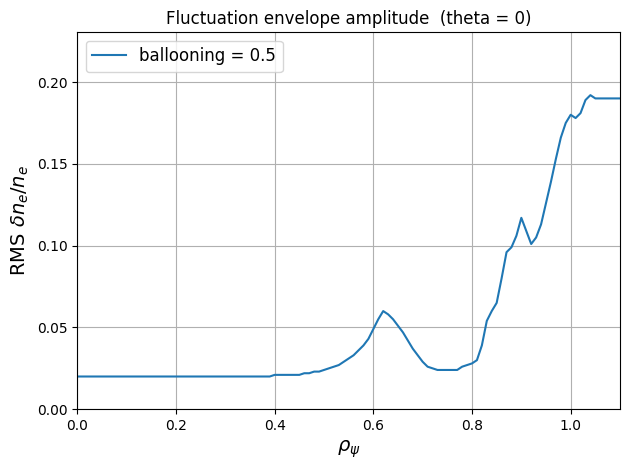

{'__name__': '__main__',
 '__doc__': 'Model for the fluctuation envelope amplitude.\n\nThe fluctuation amplitude is factored into a radial profile (read from\nnefluct.dat in the same directory as this file) and a poloidal ballooning\nenvelope:\n\n    delta_ne/ne(rho, theta) = A_rho(rho) * A_theta(theta)\n\nwhere\n\n    A_theta(theta) = 0.5 * (1 + ballooning + (1 - ballooning) * cos(theta))\n\n    ballooning=1  →  isotropic  (A_theta = 1 everywhere)\n    ballooning=0  →  fully ballooned  (A_theta = cos^2(theta/2))\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/home/devlamin/WKbeam_simulations/TCV_88617_1.25_fluct/input/fluct_amplitude.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, exceptions, and other objects.\n\nNoteworthy: None is the `nil' object; Ellipsis represents `...' in slices.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins',

In [90]:
%matplotlib inline
import importlib, sys as _sys

# Run the generated fluct_amplitude.py as __main__ to show the profile plot
_fluct_path = os.path.join(sim.sim_dir, 'input', 'fluct_amplitude.py')
import runpy
runpy.run_path(_fluct_path, run_name='__main__')